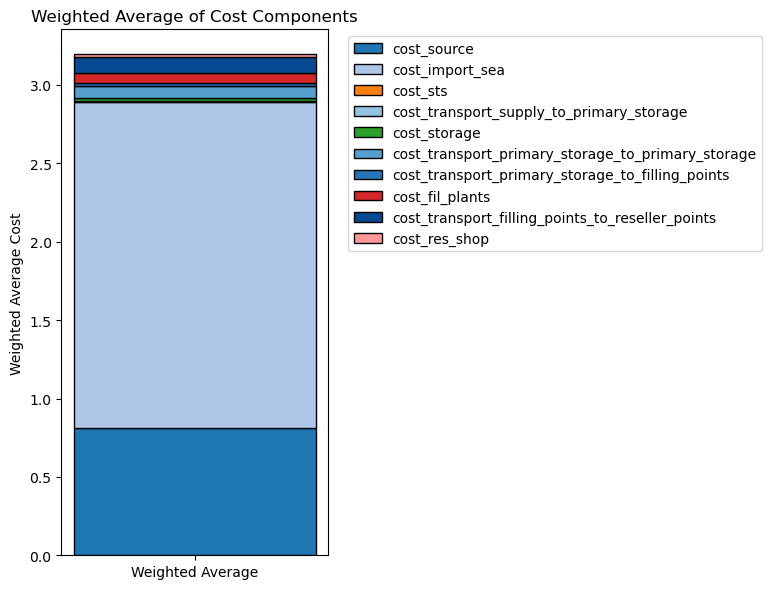

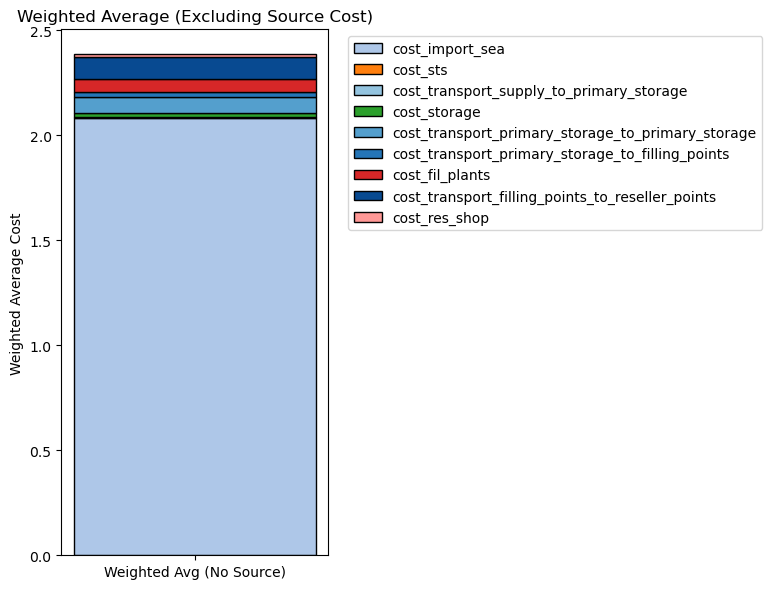

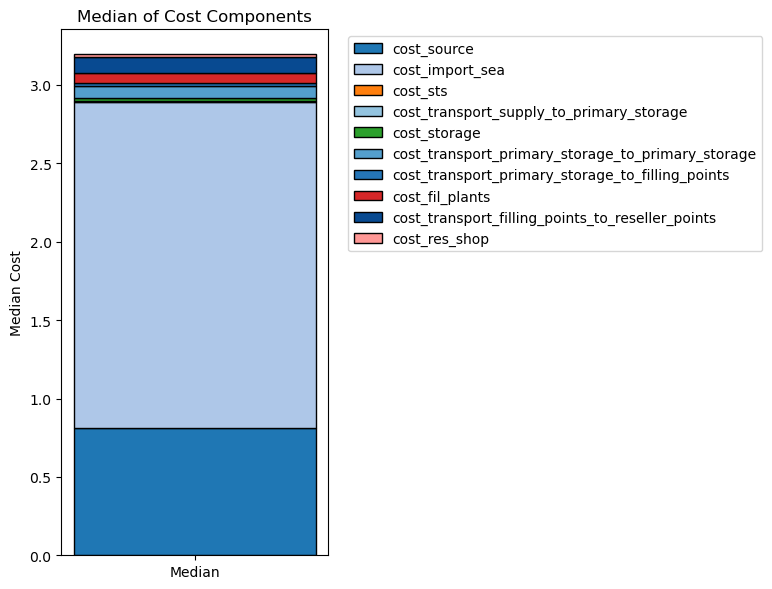

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Load the dataset
file_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\ALTRI COUNTRY\MDG\supply_chain_layer_MDG.gpkg"
layer_name = "reseller_points"

gdf = gpd.read_file(file_path, layer=layer_name)
clients_col = 'clients'

# 2. Select cost columns
cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
if 'cost_total' in cost_cols:
    cost_cols.remove('cost_total')

gdf_clean = gdf.dropna(subset=[clients_col]).copy()

# Calculation 1: Weighted average
weighted_avg = {}
for col in cost_cols:
    valid_data = gdf_clean.dropna(subset=[col])
    total_valid_clients = valid_data[clients_col].sum()
    if total_valid_clients > 0:
        weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
    else:
        weighted_avg[col] = 0

# Calculation 2: Weighted average excluding "cost_source"
weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

# Calculation 3: Median
medians = gdf[cost_cols].median().to_dict()

# --- Color Mapping Logic ---
# Identify transport costs vs other costs
transport_cols = [col for col in cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in cost_cols if col not in transport_cols]

cost_colors = {}

# Assign similar colors (shades of Blue) to transport costs
transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    # Avoid colors that are too light to see on a white background (start from 0.4)
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) 
    cost_colors[col] = transport_cmap(shade_intensity)

# Assign distinct, separate colors to all other costs
other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# 3. Create the plots
def plot_stacked_bar(data_dict, title, ylabel, bar_label):
    plt.figure(figsize=(8, 6))
    bottom = 0
    
    for cost_name, value in data_dict.items():
        # Exclude components with a value of 0
        if value > 0:
            plt.bar(
                bar_label, 
                value, 
                bottom=bottom, 
                label=cost_name, 
                color=cost_colors[cost_name], 
                edgecolor='black'
            )
            bottom += value
            
    plt.title(title)
    plt.ylabel(ylabel)
    
    # Only show legend if there are valid items plotted
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

# Generate the 3 separate plots
plot_stacked_bar(
    data_dict=weighted_avg, 
    title='Weighted Average of Cost Components', 
    ylabel='Weighted Average Cost', 
    bar_label='Weighted Average'
)

plot_stacked_bar(
    data_dict=weighted_avg_no_source, 
    title='Weighted Average (Excluding Source Cost)', 
    ylabel='Weighted Average Cost', 
    bar_label='Weighted Avg (No Source)'
)

plot_stacked_bar(
    data_dict=medians, 
    title='Median of Cost Components', 
    ylabel='Median Cost', 
    bar_label='Median'
)


--- Weighted Average ---
                                   Cost Component    Value
                                      cost_source 0.731837
                                 cost_import_land 0.045379
                                 cost_border_wait 0.001113
         cost_transport_supply_to_primary_storage 0.006880
                                     cost_storage 0.020049
cost_transport_primary_storage_to_primary_storage 0.001846
 cost_transport_primary_storage_to_filling_points 0.000753
                                  cost_fil_plants 0.054631
 cost_transport_filling_points_to_reseller_points 0.005936
                                    cost_res_shop 0.018538
                                            Total 0.886961

--- Weighted Average (No Source) ---
                                   Cost Component    Value
                                 cost_import_land 0.045379
                                 cost_border_wait 0.001113
         cost_transport_supply_to_primary_storage 0

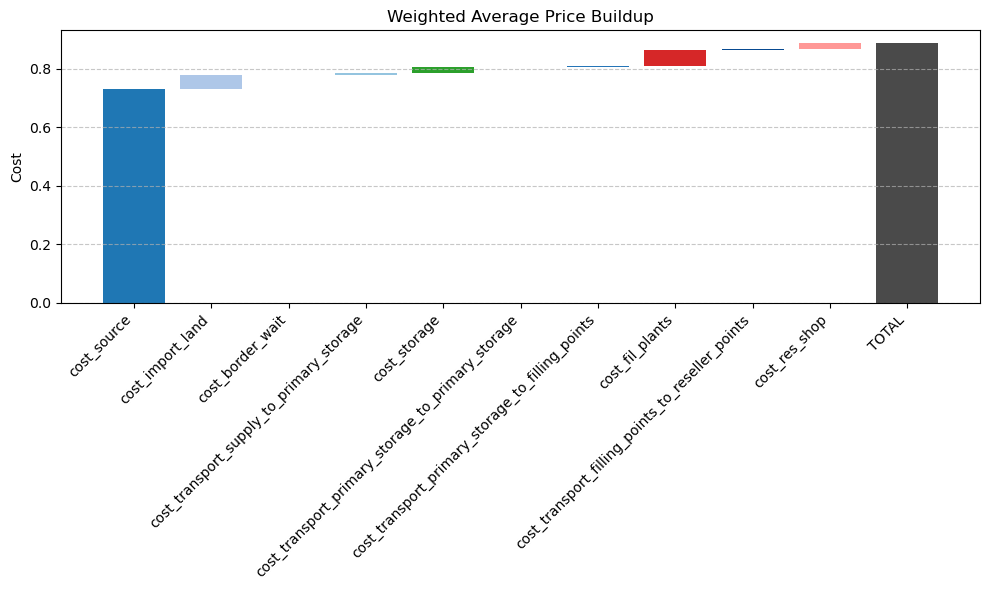

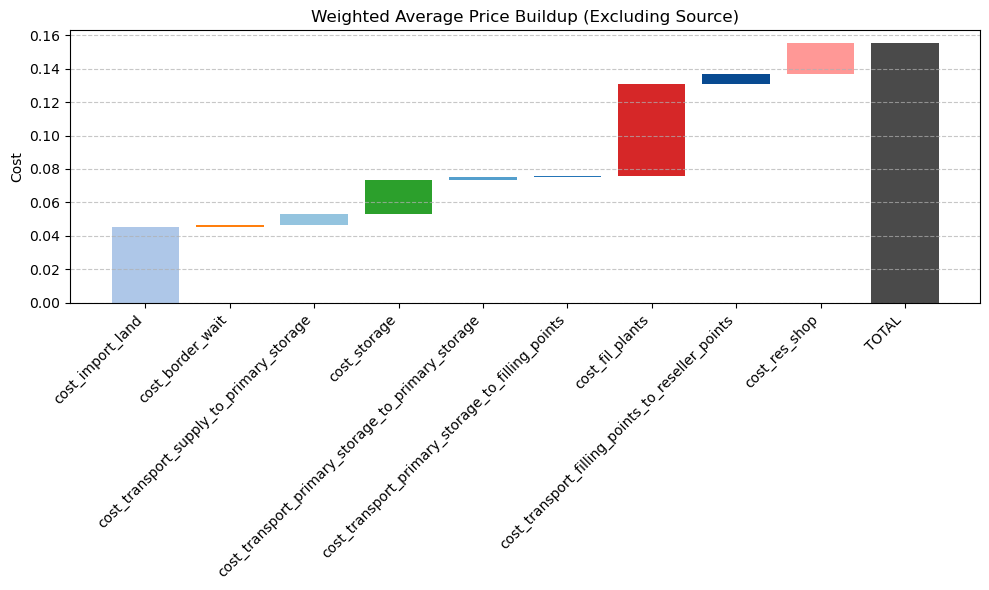

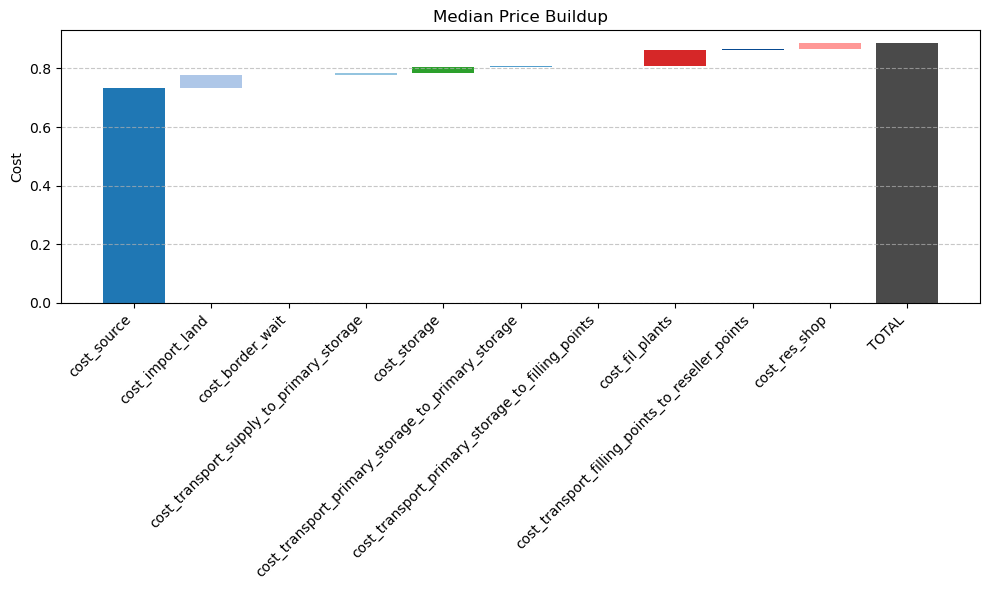

In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Load the dataset
file_path = file_path
layer_name = "reseller_points"

gdf = gpd.read_file(file_path, layer=layer_name)
clients_col = 'clients'

# 2. Select cost columns
cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
if 'cost_total' in cost_cols:
    cost_cols.remove('cost_total')

gdf_clean = gdf.dropna(subset=[clients_col]).copy()

# Calculation 1: Weighted average
weighted_avg = {}
for col in cost_cols:
    valid_data = gdf_clean.dropna(subset=[col])
    total_valid_clients = valid_data[clients_col].sum()
    if total_valid_clients > 0:
        weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
    else:
        weighted_avg[col] = 0

# Calculation 2: Weighted average excluding "cost_source"
weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

# Calculation 3: Median
medians = gdf[cost_cols].median().to_dict()

# --- Color Mapping Logic ---
transport_cols = [col for col in cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in cost_cols if col not in transport_cols]

cost_colors = {}
transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) 
    cost_colors[col] = transport_cmap(shade_intensity)

other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# --- Print Tables ---
def print_table(data_dict, title):
    # Filter out 0 values for the table as well
    filtered_data = {k: v for k, v in data_dict.items() if v > 0}
    filtered_data['Total'] = sum(filtered_data.values())
    df = pd.DataFrame(list(filtered_data.items()), columns=['Cost Component', 'Value'])
    print(f"\n--- {title} ---")
    print(df.to_string(index=False))

print_table(weighted_avg, "Weighted Average")
print_table(weighted_avg_no_source, "Weighted Average (No Source)")
print_table(medians, "Medians")

# --- Waterfall Plot Logic ---
def plot_waterfall(data_dict, title, ylabel):
    # Filter 0 values
    data = {k: v for k, v in data_dict.items() if v > 0}
    if not data:
        return
    
    labels = list(data.keys()) + ['TOTAL']
    values = list(data.values())
    total_val = sum(values)
    values.append(total_val)
    
    # Calculate bottom positions for the floating bars
    bottoms = []
    current_bottom = 0
    
    for i, val in enumerate(values[:-1]):
        if i == 0:
            bottoms.append(0)  # First bar starts at 0
        else:
            bottoms.append(current_bottom) # Subsequent bars float
        current_bottom += val
        
    bottoms.append(0)  # Final Total bar starts at 0
    
    # Set colors
    colors = [cost_colors.get(label, '#1f77b4') for label in labels[:-1]]
    colors.append('#4a4a4a')  # Dark grey for the TOTAL bar
    
    plt.figure(figsize=(10, 6))
    
    plt.bar(labels, values, bottom=bottoms, color=colors, edgecolor='none')
    
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    
    # Add horizontal gridlines for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate the 3 waterfall plots
plot_waterfall(weighted_avg, 'Weighted Average Price Buildup', 'Cost')
plot_waterfall(weighted_avg_no_source, 'Weighted Average Price Buildup (Excluding Source)', 'Cost')
plot_waterfall(medians, 'Median Price Buildup', 'Cost')